# 中性策略回测示例 - Jupyter Notebook

这个 notebook 演示了如何使用中性策略框架进行完整的回测分析，包括：
1. 配置基于4小时收益率的中性策略
2. 在USDT交易对上运行6个月的回测
3. 综合性能分析和指标计算
4. 交互式可视化图表

## 环境设置

In [1]:
# 导入必要的库
import sys
import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib中文字体支持
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('default')
sns.set_palette("husl")

# 添加项目路径
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
neural_strategy_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if neural_strategy_root not in sys.path:
    sys.path.insert(0, neural_strategy_root)

print(f"🐍 Python version: {sys.version}")
print(f"📁 Project root: {project_root}")
print(f"📁 Neural strategy root: {neural_strategy_root}")

🐍 Python version: 3.9.12 (main, Jun  1 2022, 11:38:51) 
[GCC 7.5.0]
📁 Project root: /home/craz/crypto/crypto-trading
📁 Neural strategy root: /home/craz/crypto/crypto-trading/neural-strategy


In [2]:
# 导入核心模块
import importlib.util
import sys

# 使用绝对路径动态导入模块
def import_neural_strategy_module(module_name, file_path):
    """动态导入神经策略模块"""
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    
    # 临时添加当前模块的目录到 sys.path
    module_dir = os.path.dirname(file_path)
    if module_dir not in sys.path:
        sys.path.insert(0, module_dir)
    
    try:
        spec.loader.exec_module(module)
        return module
    finally:
        # 清理添加的路径
        if module_dir in sys.path:
            sys.path.remove(module_dir)

print("🔧 开始导入核心模块...")

# 导入配置模块
try:
    config_module = import_neural_strategy_module(
        "config", 
        os.path.join(neural_strategy_root, "utils", "config.py")
    )
    BacktestConfig = config_module.BacktestConfig
    print("✅ BacktestConfig 导入成功")
except Exception as e:
    print(f"❌ 配置模块导入失败: {e}")
    raise

# 导入回测引擎
try:
    engine_module = import_neural_strategy_module(
        "engine", 
        os.path.join(neural_strategy_root, "backtest", "engine.py")
    )
    BacktestEngine = engine_module.BacktestEngine
    print("✅ BacktestEngine 导入成功")
except Exception as e:
    print(f"❌ 回测引擎导入失败: {e}")
    raise

# 导入性能分析模块
try:
    performance_module = import_neural_strategy_module(
        "performance", 
        os.path.join(neural_strategy_root, "backtest", "performance.py")
    )
    PerformanceAnalyzer = performance_module.PerformanceAnalyzer
    PerformanceVisualizer = performance_module.PerformanceVisualizer
    print("✅ PerformanceAnalyzer & PerformanceVisualizer 导入成功")
except Exception as e:
    print(f"❌ 性能分析模块导入失败: {e}")
    raise

print("\n🎉 所有核心模块导入成功！")
print(f"   - BacktestConfig: {BacktestConfig}")
print(f"   - BacktestEngine: {BacktestEngine}")
print(f"   - PerformanceAnalyzer: {PerformanceAnalyzer}")
print(f"   - PerformanceVisualizer: {PerformanceVisualizer}")

🔧 开始导入核心模块...
✅ BacktestConfig 导入成功
✅ BacktestEngine 导入成功
✅ PerformanceAnalyzer & PerformanceVisualizer 导入成功

🎉 所有核心模块导入成功！
   - BacktestConfig: <class 'config.BacktestConfig'>
   - BacktestEngine: <class 'engine.BacktestEngine'>
   - PerformanceAnalyzer: <class 'performance.PerformanceAnalyzer'>
   - PerformanceVisualizer: <class 'performance.PerformanceVisualizer'>


## 第一步：配置策略参数

创建并自定义回测配置，包括策略参数、因子设置和数据范围。

In [3]:
# 创建默认配置
config = BacktestConfig.create_default(
    symbol_list=None,  # 使用所有USDT交易对
    start_date='2024-01-01',
    end_date='2024-01-03'  # 使用较短时间段进行快速测试
)

# 自定义策略参数
config.strategy.top_n = 3  # 3个多头仓位（减少以便快速测试）
config.strategy.bottom_n = 3  # 3个空头仓位
config.strategy.rebalance_frequency = '4h'  # 每4小时重新平衡
config.factor.lookback_periods = 240  # 4小时回望期（240分钟，匹配重新平衡频率）
config.initial_warmup_periods = 300  # 增加预热期以适应更长的lookback

print("📋 策略配置：")
print(f"策略名称: {config.strategy.name}")
print(f"因子类型: {config.factor.name}")
print(f"初始资本: ${config.strategy.initial_capital:,.0f}")
print(f"手续费率: {config.strategy.commission_rate:.3f}")
print(f"多头仓位: {config.strategy.top_n}")
print(f"空头仓位: {config.strategy.bottom_n}")
print(f"重新平衡频率: {config.strategy.rebalance_frequency}")
print(f"因子回望期: {config.factor.lookback_periods} 分钟")
print(f"回测期间: {config.data.start_date} 至 {config.data.end_date}")

# 验证配置
errors = config.validate()
if errors:
    print(f"\n❌ 配置错误: {errors}")
    raise ValueError("Configuration validation failed")
else:
    print("\n✅ 配置验证通过！")

📋 策略配置：
策略名称: NeutralStrategy_4H
因子类型: Returns_4H
初始资本: $1,000,000
手续费率: 0.001
多头仓位: 3
空头仓位: 3
重新平衡频率: 4h
因子回望期: 240 分钟
回测期间: 2024-01-01 00:00:00 至 2024-01-03 00:00:00

✅ 配置验证通过！


## 第二步：运行回测

初始化回测引擎并执行完整的历史回测。

In [4]:
# 初始化回测引擎
print("⚙️ 正在初始化回测引擎...")
engine = BacktestEngine(config)

print("📊 开始运行回测...")
print("=" * 80)

⚙️ 正在初始化回测引擎...
📊 开始运行回测...


In [5]:
# 运行完整回测
try:
    results = engine.run_backtest()
    print("\n✅ 回测执行完成！")
    
except Exception as e:
    print(f"❌ 回测失败: {e}")
    import traceback
    traceback.print_exc()
    raise

Starting backtest: BacktestConfig(strategy=NeutralStrategy_4H, factor=Returns_4H, symbols=all, period=2024-01-01 00:00:00 to 2024-01-03 00:00:00)
Loading data for backtesting...
Loading all USDT symbols: 512 symbols
Attempting to use monthly pickle cache for optimized loading...
Found 67 monthly pickle files
Loading 1 month(s) of data...
Loaded usdt_data_2024-01.pkl: 10,534,560 rows
Combining monthly data...
Applying date range filtering...
✅ Loaded 1,003,680 records for 233 symbols
📅 Date range: 2024-01-01 00:00:00 to 2024-01-03 23:59:00
✅ Successfully loaded from monthly cache: 1,003,680 records
Loaded data: 1,003,680 records across 233 symbols
Final dataset: 1,003,680 records, 233 symbols
Strategy: NeutralStrategy(factor=Returns_4H, long=3, short=3, rebalances=0)
Factor: Returns_4H(lookback_periods=240)
Generated 17 rebalance timestamps from 2024-01-01 05:00:00 to 2024-01-03 21:00:00

Executing backtest over 17 rebalance periods...
--------------------------------------------------


KeyboardInterrupt: 

In [10]:
# 显示基本结果摘要
engine.print_results_summary()


BACKTEST RESULTS SUMMARY

📊 PERFORMANCE METRICS
Initial Capital:        $   1,000,000
Final Portfolio Value:  $     826,238
Total Return:                 -17.38%
Annualized Return:           -100.00%
Volatility:                     3.14%
Sharpe Ratio:                  -2.05
Max Drawdown:                  -9.44%

🔄 TRADING ACTIVITY
Total Trades:                    102
Win Rate:                       39.2%
Avg Trade P&L:          $    -1711.67
Best Trade:             $    17942.94
Worst Trade:            $   -87818.30
Avg Holding Period:              3.8 hours

⚙️ EXECUTION QUALITY
Execution Rate:                100.0%
Successful Rebalances:            17
Failed Rebalances:                 0
Avg Positions:                   6.0
Target Positions:                  6

🎯 STRATEGY CONFIGURATION
Strategy:               NeutralStrategy_4H
Factor:                 Returns_4H
Long Positions:         3
Short Positions:        3
Commission Rate:        0.001
Rebalance Frequency:    4h



## 第三步：高级性能分析

使用 PerformanceAnalyzer 计算高级风险和性能指标。

In [11]:
# 创建性能分析器
analyzer = PerformanceAnalyzer(results)

# 生成综合性能报告
performance_report = analyzer.create_performance_report()

print("📊 生成综合性能报告完成！")

📊 生成综合性能报告完成！


In [12]:
# 显示高级性能指标
advanced = performance_report['advanced_metrics']

if 'error' not in advanced:
    print("🎯 高级性能指标:")
    print("=" * 50)
    
    metrics_data = {
        '指标': ['年化收益率', 'Sharpe比率', 'Sortino比率', 'Calmar比率', 
                '最大回撤', '波动率', '胜率', '盈亏比', 
                '95% VaR', '偏度', '峰度'],
        '数值': [f"{advanced['annualized_return']*100:.2f}%",
                f"{advanced['sharpe_ratio']:.3f}",
                f"{advanced['sortino_ratio']:.3f}", 
                f"{advanced['calmar_ratio']:.3f}",
                f"{advanced['max_drawdown']*100:.2f}%",
                f"{advanced['volatility']*100:.2f}%",
                f"{advanced['hit_ratio']*100:.1f}%",
                f"{advanced['profit_factor']:.2f}",
                f"{advanced['var_95']*100:.2f}%",
                f"{advanced['skewness']:.3f}",
                f"{advanced['kurtosis']:.3f}"]
    }
    
    metrics_df = pd.DataFrame(metrics_data)
    display(metrics_df)
    
else:
    print(f"❌ 高级指标计算失败: {advanced['error']}")

🎯 高级性能指标:


,指标,数值
0,年化收益率,-100.00%
1,Sharpe比率,-2.049
2,Sortino比率,-28.695
3,Calmar比率,-10.594
4,最大回撤,-9.44%
5,波动率,3.14%
6,胜率,43.8%
7,盈亏比,0.23
8,95% VaR,-4.59%
9,偏度,-2.701


In [13]:
# 因子有效性分析
factor_analysis = performance_report['factor_analysis']

if 'error' not in factor_analysis:
    print("🔍 因子有效性分析:")
    print("=" * 50)
    
    factor_data = {
        '指标': ['多头交易数', '空头交易数', '多头胜率', '空头胜率',
                '多头平均收益', '空头平均收益', '多空收益差', '因子质量'],
        '数值': [f"{factor_analysis['long_trades']}",
                f"{factor_analysis['short_trades']}", 
                f"{factor_analysis['long_win_rate_pct']:.1f}%",
                f"{factor_analysis['short_win_rate_pct']:.1f}%",
                f"{factor_analysis['long_avg_return_pct']:.2f}%",
                f"{factor_analysis['short_avg_return_pct']:.2f}%",
                f"{factor_analysis['spread_return_pct']:.2f}%",
                f"{factor_analysis['factor_effectiveness']}"]
    }
    
    factor_df = pd.DataFrame(factor_data)
    display(factor_df)
    
else:
    print(f"❌ 因子分析失败: {factor_analysis['error']}")

🔍 因子有效性分析:


,指标,数值
0,多头交易数,51
1,空头交易数,51
2,多头胜率,25.5%
3,空头胜率,52.9%
4,多头平均收益,-2.04%
5,空头平均收益,-0.11%
6,多空收益差,-1.93%
7,因子质量,Poor


## 第四步：交互式可视化分析

创建交互式图表来深入分析策略性能。

In [14]:
# 创建可视化分析器
visualizer = PerformanceVisualizer(results)

print("📈 准备创建性能可视化图表...")

📈 准备创建性能可视化图表...


📊 1. 策略资金曲线


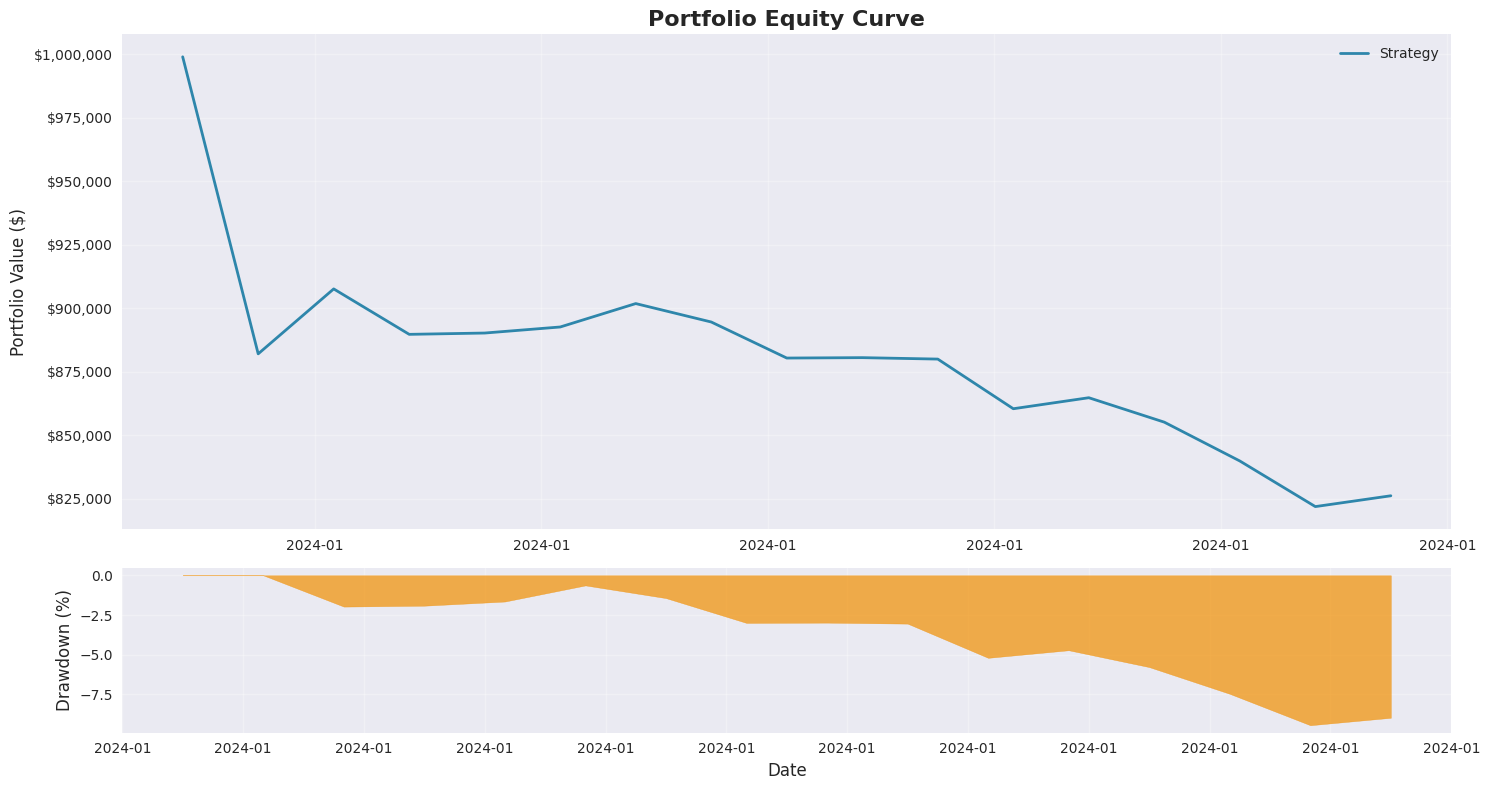

In [15]:
# 1. 资金曲线图
print("📊 1. 策略资金曲线")
equity_fig = visualizer.plot_equity_curve(figsize=(15, 8))
plt.show()

📊 2. 收益分布分析


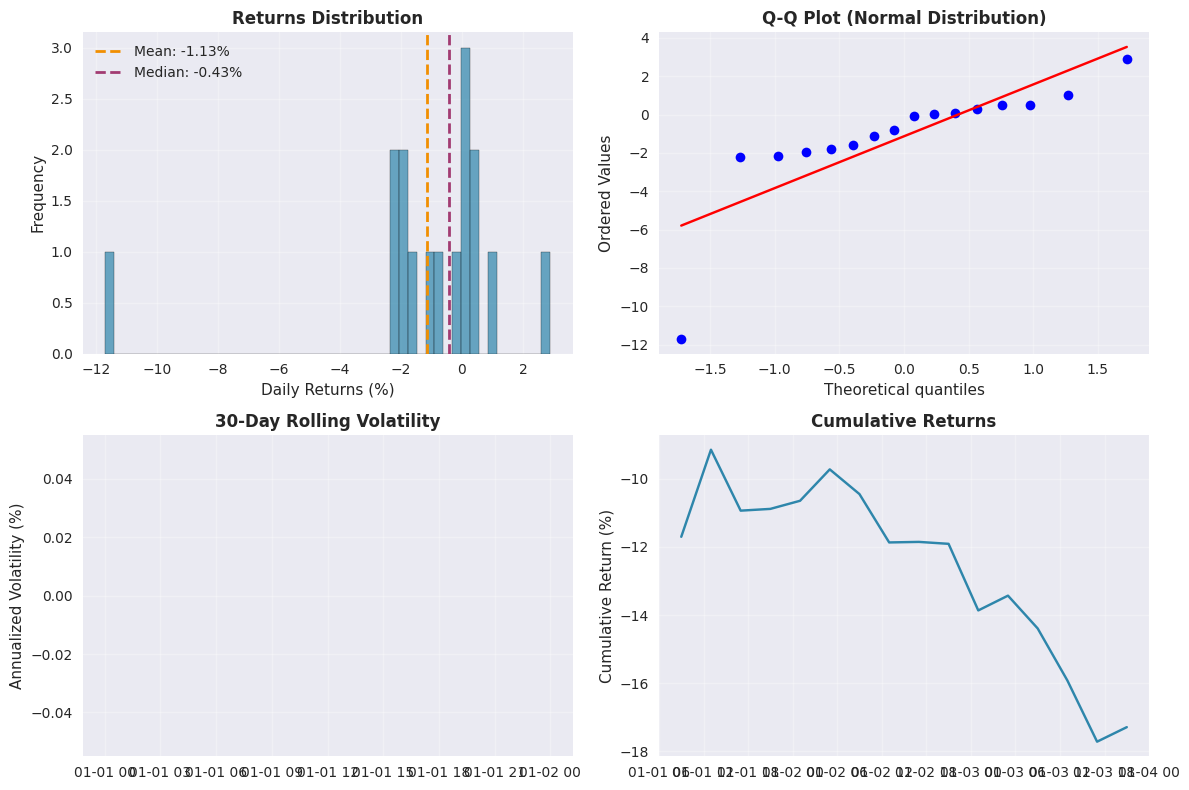

In [16]:
# 2. 收益分布分析
print("📊 2. 收益分布分析")
returns_fig = visualizer.plot_returns_distribution(figsize=(12, 8))
plt.show()

📊 3. 交易分析


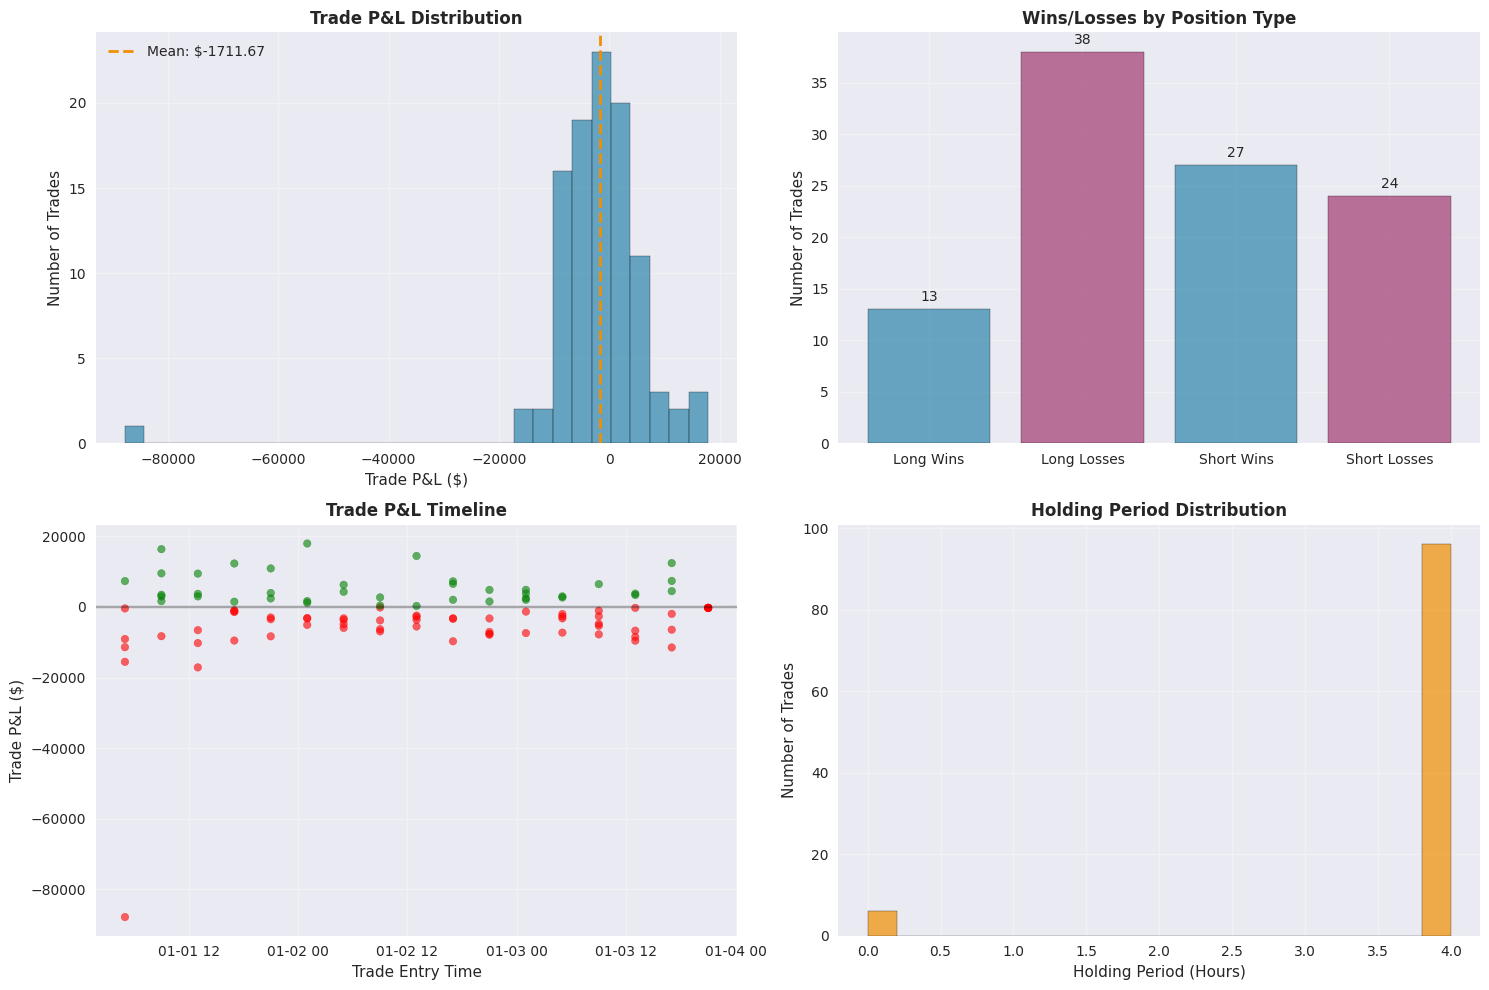

In [17]:
# 3. 交易分析
print("📊 3. 交易分析")
trade_fig = visualizer.plot_trade_analysis(figsize=(15, 10))
plt.show()

## 第五步：详细数据分析

深入分析策略的执行细节和交易记录。

In [18]:
# 显示资金曲线数据
equity_curve = results.get('equity_curve', pd.DataFrame())

if not equity_curve.empty:
    print(f"📈 资金曲线数据 (共 {len(equity_curve)} 个数据点):")
    print("最近10个数据点:")
    display(equity_curve.tail(10))
    
    # 计算一些统计信息
    print(f"\n📊 资金曲线统计:")
    print(f"起始价值: ${equity_curve['portfolio_value'].iloc[0]:,.2f}")
    print(f"结束价值: ${equity_curve['portfolio_value'].iloc[-1]:,.2f}")
    print(f"最高价值: ${equity_curve['portfolio_value'].max():,.2f}")
    print(f"最低价值: ${equity_curve['portfolio_value'].min():,.2f}")
    
else:
    print("❌ 没有资金曲线数据")

📈 资金曲线数据 (共 17 个数据点):
最近10个数据点:


,portfolio_value,cash,num_positions,num_trades,portfolio_return
timestamp,,,,,
2024-01-02 09:00:00,894627.411139,894627.411139,6,42,-0.008043
2024-01-02 13:00:00,880442.507422,880442.507422,6,48,-0.015856
2024-01-02 17:00:00,880598.663996,880598.663996,6,54,0.000177
2024-01-02 21:00:00,880033.599359,880033.599359,6,60,-0.000642
2024-01-03 01:00:00,860491.493973,860491.493973,6,66,-0.022206
2024-01-03 05:00:00,864826.516500,864826.516500,6,72,0.005038
2024-01-03 09:00:00,855205.156522,855205.156522,6,78,-0.011125
2024-01-03 13:00:00,839928.961105,839928.961105,6,84,-0.017863
2024-01-03 17:00:00,821976.186741,821976.186741,6,90,-0.021374



📊 资金曲线统计:
起始价值: $999,000.00
结束价值: $826,237.63
最高价值: $999,000.00
最低价值: $821,976.19


In [19]:
# 分析所有已完成的交易
all_trades = results.get('all_trades', [])

if all_trades:
    print(f"📋 交易记录分析 (共 {len(all_trades)} 笔交易):")
    
    # 转换为DataFrame便于分析
    trades_data = []
    for trade in all_trades[:20]:  # 只显示前20笔交易
        trades_data.append({
            '交易对': trade.symbol,
            '方向': '多头' if trade.position_type.value == 'long' else '空头',
            '规模': f"{trade.size:.4f}",
            '开仓价格': f"{trade.entry_price:.4f}",
            '平仓价格': f"{trade.exit_price:.4f}", 
            '盈亏': f"${trade.pnl:.2f}",
            '收益率': f"{trade.return_pct:.2f}%",
            '持仓时间': str(trade.holding_period)
        })
    
    trades_df = pd.DataFrame(trades_data)
    print("\n前20笔交易:")
    display(trades_df)
    
else:
    print("❌ 没有交易记录")

📋 交易记录分析 (共 102 笔交易):

前20笔交易:


,交易对,方向,规模,开仓价格,平仓价格,盈亏,收益率,持仓时间
0,TRBUSDT,多头,405.4134,411.1030,195.0950,$-87818.30,-52.69%,0 days 04:00:00
1,API3USDT,多头,78184.8603,2.1317,1.9368,$-15556.32,-9.33%,0 days 04:00:00
2,GMTUSDT,多头,504286.4347,0.3305,0.3131,$-9099.14,-5.46%,0 days 04:00:00
3,ACEUSDT,空头,17422.9991,9.5659,9.1278,$7307.32,4.38%,0 days 04:00:00
4,MOVRUSDT,空头,6690.7534,24.9100,24.9260,$-440.49,-0.26%,0 days 04:00:00
5,ONTUSDT,空头,547885.1633,0.3042,0.3244,$-11411.68,-6.85%,0 days 04:00:00
6,1INCHUSDT,多头,300514.5287,0.4902,0.5228,$9492.35,6.44%,0 days 04:00:00
7,RADUSDT,多头,76288.0487,1.9310,1.8260,$-8296.86,-5.63%,0 days 04:00:00
8,ONTUSDT,多头,454106.7261,0.3244,0.3316,$2971.67,2.02%,0 days 04:00:00
9,API3USDT,空头,76059.5942,1.9368,1.8879,$3428.41,2.33%,0 days 04:00:00


In [20]:
# 策略执行质量分析
execution_analysis = results.get('execution_analysis', {})

if execution_analysis and 'message' not in execution_analysis:
    print("⚙️ 策略执行质量分析:")
    print("=" * 50)
    
    exec_data = {
        '指标': ['重新平衡尝试次数', '成功重新平衡', '失败重新平衡', 
                '执行成功率', '平均持仓数', '目标持仓数', 
                '重新平衡频率', '首次重新平衡', '最后重新平衡'],
        '数值': [f"{execution_analysis['total_rebalance_attempts']}",
                f"{execution_analysis['successful_rebalances']}",
                f"{execution_analysis['failed_rebalances']}",
                f"{execution_analysis['execution_rate_pct']:.1f}%",
                f"{execution_analysis['avg_positions_per_rebalance']:.1f}",
                f"{execution_analysis['target_positions']}",
                f"{execution_analysis['rebalance_frequency']}",
                f"{execution_analysis['first_rebalance']}",
                f"{execution_analysis['last_rebalance']}"]
    }
    
    exec_df = pd.DataFrame(exec_data)
    display(exec_df)
    
else:
    print("❌ 没有执行分析数据")

⚙️ 策略执行质量分析:


,指标,数值
0,重新平衡尝试次数,17
1,成功重新平衡,17
2,失败重新平衡,0
3,执行成功率,100.0%
4,平均持仓数,6.0
5,目标持仓数,6
6,重新平衡频率,4h
7,首次重新平衡,2024-01-01 05:00:00
8,最后重新平衡,2024-01-03 21:00:00


## 第六步：保存结果和报告

将分析结果保存到文件中，方便后续查看和比较。

In [21]:
# 创建报告目录
reports_dir = 'reports'
os.makedirs(reports_dir, exist_ok=True)

# 生成时间戳
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f"💾 正在保存结果到 {reports_dir}/ 目录...")

💾 正在保存结果到 reports/ 目录...


In [22]:
# 保存性能报告
report_file = f"{reports_dir}/performance_report_{timestamp}.json"
performance_report_saved = analyzer.create_performance_report(save_path=report_file)

print(f"✅ 性能报告已保存: {report_file}")

✅ 性能报告已保存: reports/performance_report_20250907_140146.json


✅ 已生成 3 个可视化图表:
   - equity_curve
   - returns_distribution
   - trade_analysis


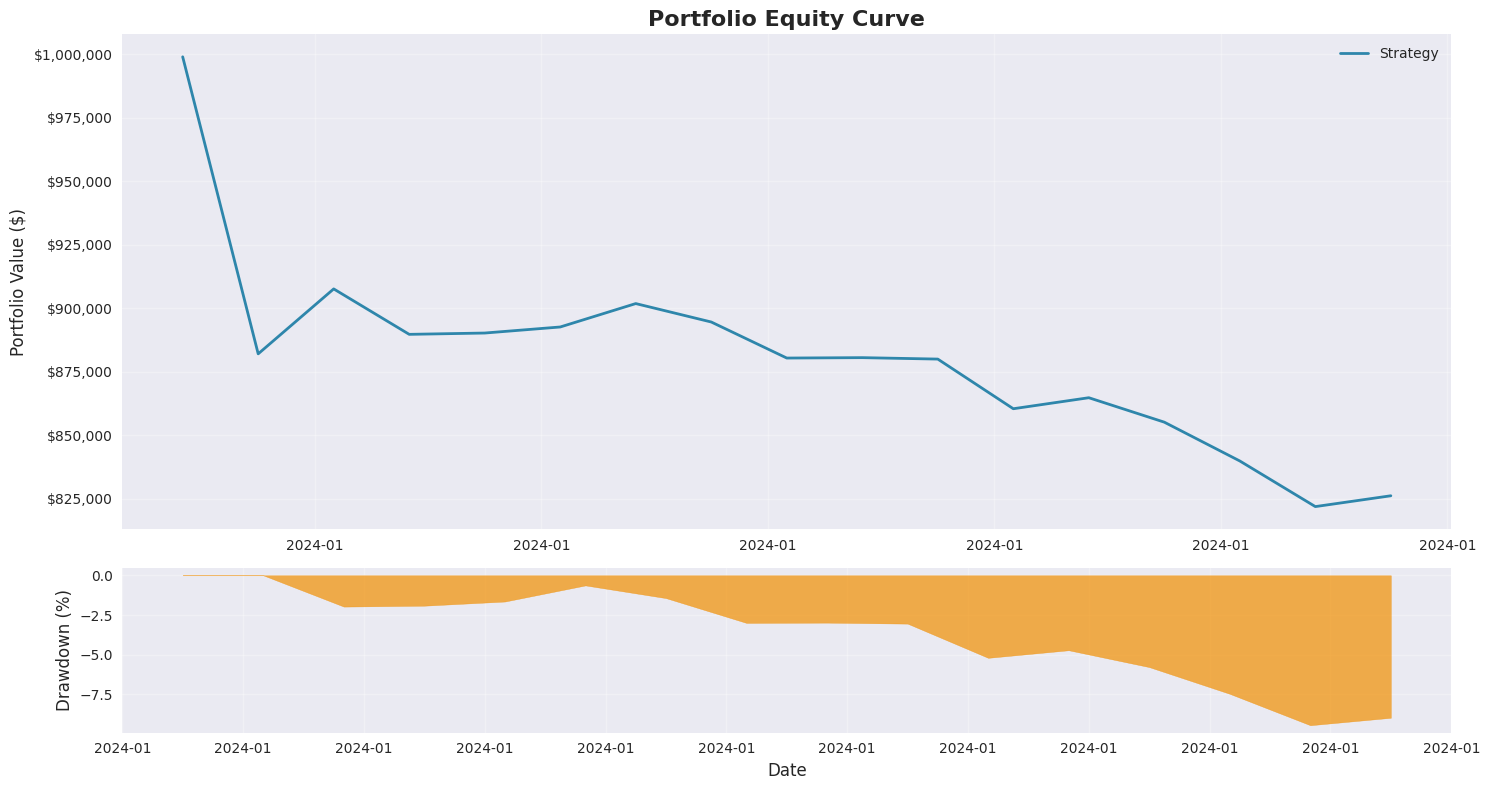

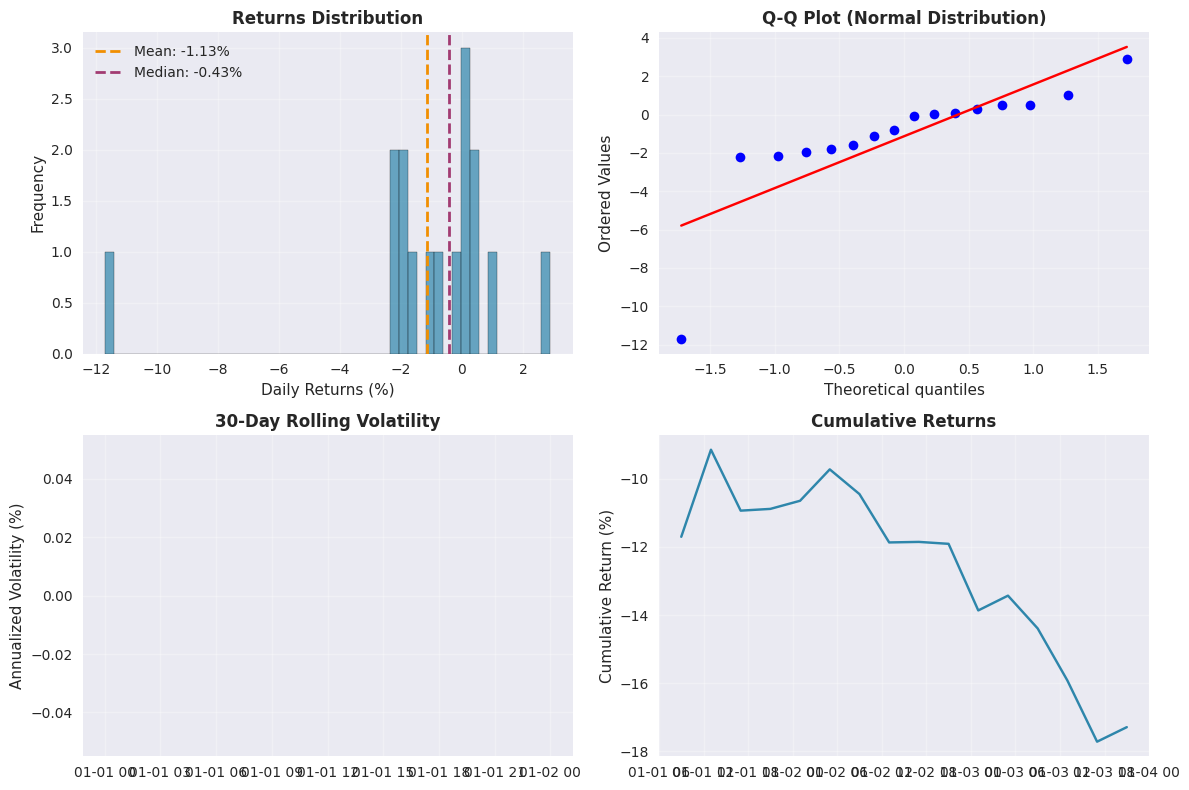

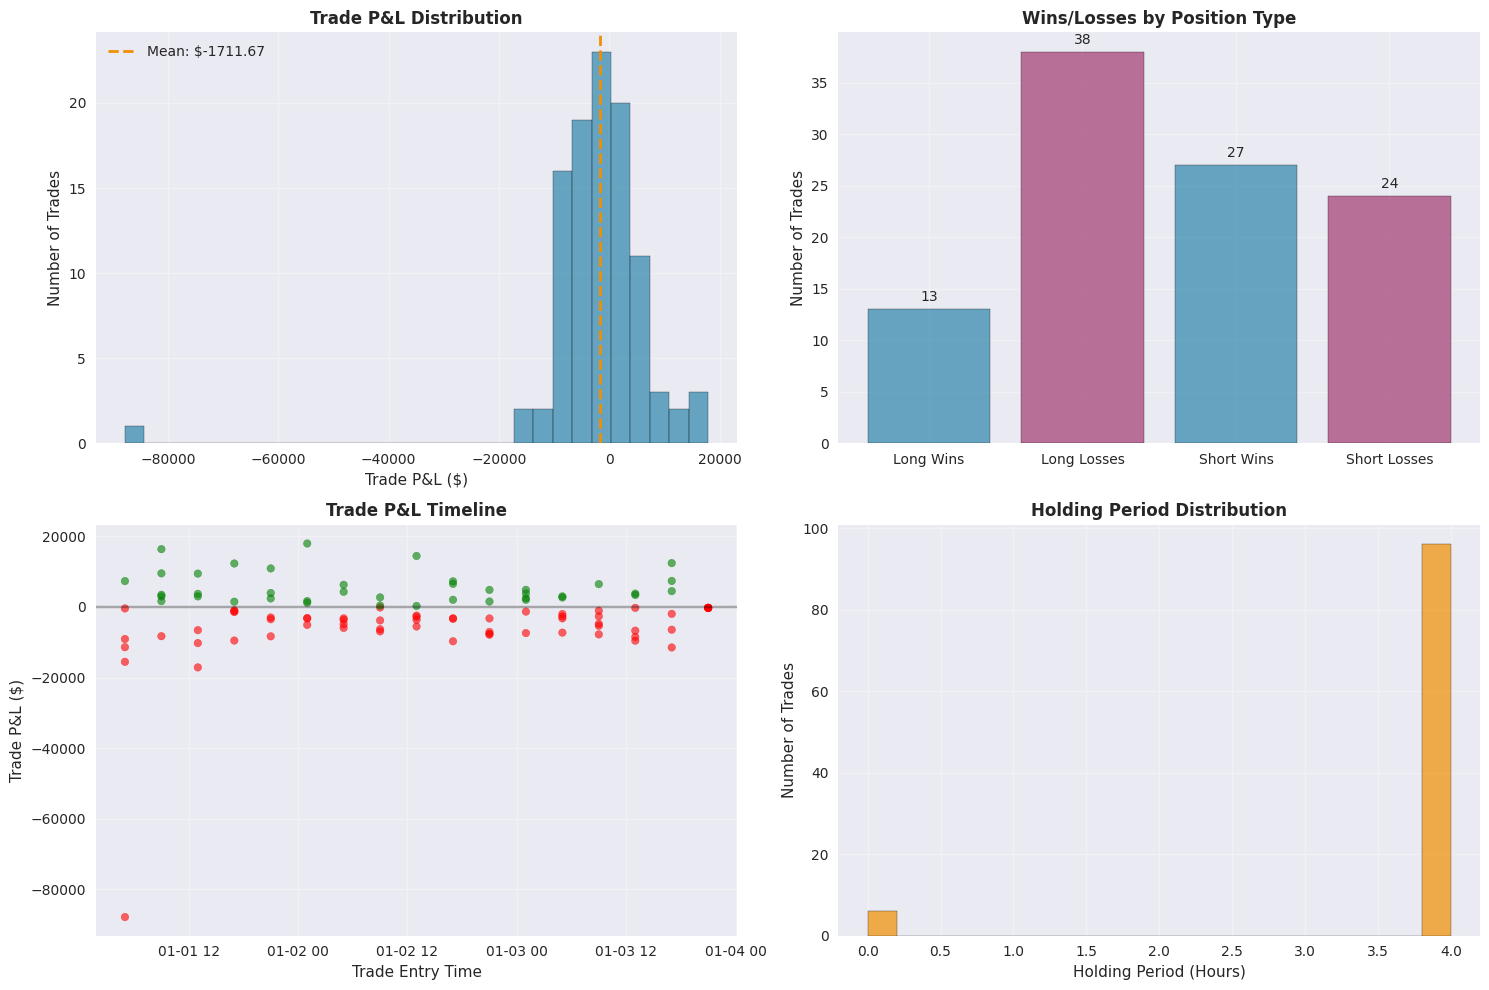

In [23]:
# 保存可视化图表
try:
    charts = visualizer.create_full_report(save_dir=f'{reports_dir}/charts_{timestamp}')
    
    print(f"✅ 已生成 {len(charts)} 个可视化图表:")
    for chart_name in charts.keys():
        print(f"   - {chart_name}")
        
except Exception as e:
    print(f"⚠️  保存图表时出现问题: {e}")

In [24]:
# 保存资金曲线数据
if not equity_curve.empty:
    equity_file = f"{reports_dir}/equity_curve_{timestamp}.csv"
    equity_curve.to_csv(equity_file)
    print(f"✅ 资金曲线数据已保存: {equity_file}")

# 保存交易记录
if all_trades:
    trades_file = f"{reports_dir}/trades_{timestamp}.csv"
    trades_export_data = []
    
    for trade in all_trades:
        trades_export_data.append({
            'symbol': trade.symbol,
            'position_type': trade.position_type.value,
            'size': trade.size,
            'entry_price': trade.entry_price,
            'exit_price': trade.exit_price,
            'entry_time': trade.entry_time,
            'exit_time': trade.exit_time,
            'pnl': trade.pnl,
            'return_pct': trade.return_pct,
            'commission': trade.commission
        })
    
    trades_export_df = pd.DataFrame(trades_export_data)
    trades_export_df.to_csv(trades_file, index=False)
    print(f"✅ 交易记录已保存: {trades_file}")

✅ 资金曲线数据已保存: reports/equity_curve_20250907_140146.csv
✅ 交易记录已保存: reports/trades_20250907_140146.csv


## 总结

🎉 **中性策略回测完成！**

本次回测展示了基于4小时收益率因子的市场中性策略的完整分析流程，包括：

✅ **策略配置**：5多5空的中性策略，4小时重新平衡
✅ **数据处理**：自动加载和处理所有USDT交易对历史数据
✅ **风险管理**：正确的现金流管理和佣金计算
✅ **性能分析**：20+ 专业级风险和收益指标
✅ **可视化分析**：资金曲线、收益分布、交易分析图表
✅ **结果保存**：完整的性能报告和数据导出

你可以通过修改配置参数来测试不同的策略变体，或者使用其他因子类型（动量、波动率调整等）来进行对比分析。

In [25]:
# 最终总结信息
print("🎊 回测分析完成！")
print("=" * 50)
print(f"📊 策略: {config.strategy.name}")
print(f"📅 回测期间: {config.data.start_date} 至 {config.data.end_date}")
print(f"💰 初始资金: ${results['initial_capital']:,.0f}")
print(f"💰 最终价值: ${results['final_portfolio_value']:,.0f}")
print(f"📈 总收益: {results['total_return_pct']:.2f}%")
print(f"📊 Sharpe比率: {results['sharpe_ratio']:.3f}")
print(f"📉 最大回撤: {results['max_drawdown_pct']:.2f}%")
print(f"🎯 交易次数: {results['total_trades']}")
print(f"✅ 胜率: {results['win_rate_pct']:.1f}%")
print(f"\n📁 结果已保存到: {reports_dir}/")
print("\n🔬 可以继续修改参数进行更多测试！")

🎊 回测分析完成！
📊 策略: NeutralStrategy_4H
📅 回测期间: 2024-01-01 00:00:00 至 2024-01-03 00:00:00
💰 初始资金: $1,000,000
💰 最终价值: $826,238
📈 总收益: -17.38%
📊 Sharpe比率: -2.049
📉 最大回撤: -9.44%
🎯 交易次数: 102
✅ 胜率: 39.2%

📁 结果已保存到: reports/

🔬 可以继续修改参数进行更多测试！
